Compare neighbor-to-neighbor transitions around repeated items across observed and control datasets. 

The lag-CRP measures the probability of recalling an item at a particular lag **given the current recall position**, conditional on items that remain available for recall. 
Here we follow up on our previous repetition-robust implementation of the Lag-CRP analysis, as well as our Repetition Lag-CRP analysis that separately tracks transitions from repeated items to their neighbors, with a new implementation that allows us to calculate the **Repetition-Neighbor Lag-CRP**.

In this analysis, we calculate transition probabilities from neighbors of the second presentation of repeated items to neighbors of the first presentation of the same repeated items, and/or vice versa.
This allows us to investigate how item repetition affects the contextual features associated with neighboring items in a study list as indicated in free recall.

For repeated items studied at positions $i$ and $j$ with spacing of at least 4 study positions, in this version of the analysis:

1. We only tabulate lag-transitions from recalls of items studied at position $j+1$ and/or $j+2$.
2. We tabulate lags according to the study position of the first presentation of the repeated item, so that we can calculate associations with neighbors of position $i$.

We optionally also or alternatively consider transitions from recalls of items studied at position $i+1$ and/or $i+2$ to neighbors of the repeated item at position $j$.

Adjust `direction` to focus on j→i or i→j neighbor transitions.

Override `control_trial_query` to define alternative control populations.


In [1]:
import os

import matplotlib.pyplot as plt

from jaxcmr.analyses.repneighborcrp import (
    plot_rep_neighbor_crp,
    subject_rep_neighbor_crp,
    test_rep_neighbor_crp_vs_control,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.repetition import make_control_dataset
def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()


In [2]:
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = [0, .23]
mixed_trial_query = "data['list_type'] > 3"
control_trial_query = "data['list_type'] == 1"
control_shuffles = 10
min_lag = 4
max_lag = 3
use_lag2 = True


In [3]:
# Parameters
data_path = "projects/repfr/results/simulations/LohnasKahana2014_BlendPositionalCMRNoStop_rerun_best_of_1.h5"
figure_dir = "projects/repfr/results/figures/fitting"
figure_str = "LohnasKahana2014_BlendPositionalCMRNoStop_rerun_best_of_1_repneighborcrp.png"
mixed_trial_query = "data['list_type'] > 3"
control_trial_query = "data['list_type'] == 1"
control_shuffles = 1
uselag2 = True
ylim = [0, 0.23]


In [4]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, mixed_trial_query)
control_dataset = make_control_dataset(data, mixed_trial_query, control_trial_query, control_shuffles)
control_mask = generate_trial_mask(control_dataset, mixed_trial_query)
datasets = [data, control_dataset]
masks = [trial_mask, control_mask]


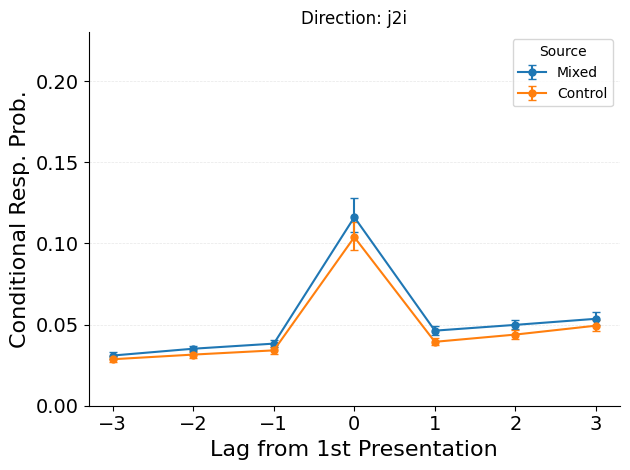

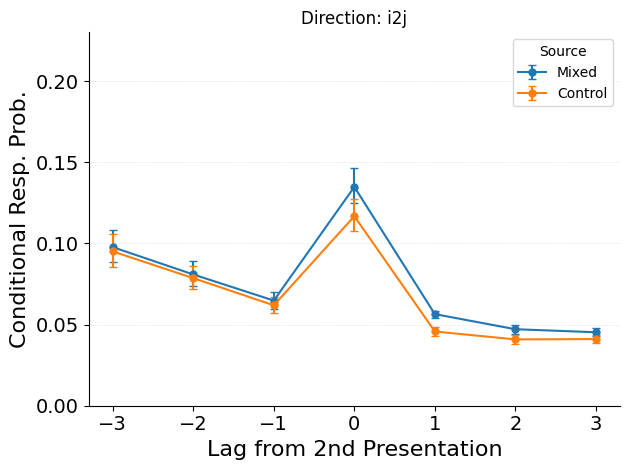

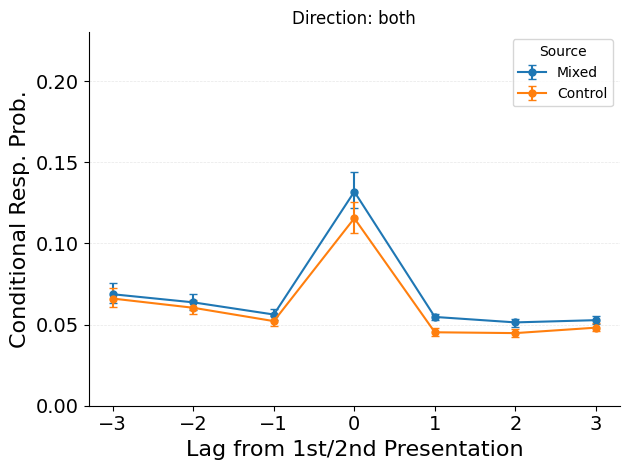

In [5]:
for direction in ["j2i", "i2j", "both"]:
    plot_rep_neighbor_crp(
        datasets=datasets,
        trial_masks=masks,
        max_lag=max_lag,
        min_lag=min_lag,
        direction=direction,
        use_lag2=use_lag2,
        contrast_name="Source",
        labels=["Mixed", "Control"],
    )
    plt.title(f"Direction: {direction}")
    if ylim is not None:
        for ax in plt.gcf().axes:
            ax.set_ylim(ylim)
    save_figure(figure_dir, figure_str, suffix=direction)


## Statistical Tests

**Hypothesis**: If seeing an item at P2 (position j) triggers retrieval of P1's context (position i), then items encoded right after P2 (j+1, j+2) should inherit some P1-context features, leading to enhanced transitions to P1's neighborhood (near position i).

**Predictions**:
- **j2i**: Should show elevated CRP if study-phase retrieval occurs (j+1/j+2 have P1 context features → transition to i-neighbors)
- **i2j**: Should NOT show the same effect (no retrieval triggered at P1)
- Asymmetry between j2i and i2j would support study-phase retrieval specifically

In [6]:
for direction in ["j2i", "i2j", "both"]:
    observed_crp = subject_rep_neighbor_crp(
        data, trial_mask, direction, use_lag2, min_lag, max_lag
    )
    control_crp = subject_rep_neighbor_crp(
        control_dataset, control_mask, direction, use_lag2, min_lag, max_lag
    )

    result = test_rep_neighbor_crp_vs_control(observed_crp, control_crp, max_lag, direction)

    print(f"\n{'='*70}")
    print(f"Statistical Test: {direction}")
    print(f"{'='*70}")
    if direction == "j2i":
        print("Tests whether j+1/j+2 → i-neighbors transitions are elevated vs control.")
        print("Significant positive effects support study-phase retrieval at P2.")
    elif direction == "i2j":
        print("Tests whether i+1/i+2 → j-neighbors transitions are elevated vs control.")
        print("(Control condition for asymmetric predictions.)")
    else:
        print("Tests both directions combined.")
    print()
    print(result)


Statistical Test: j2i
Tests whether j+1/j+2 → i-neighbors transitions are elevated vs control.
Significant positive effects support study-phase retrieval at P2.

Direction: j2i
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -3 |    2.762     0.0092 |    147.0     0.0051 |     0.0023
   -2 |    4.054     0.0003 |    102.0     0.0003 |     0.0036
   -1 |    4.272     0.0001 |     89.0     0.0001 |     0.0042
    0 |    6.267     0.0000 |     45.0     0.0000 |     0.0123
    1 |    6.293     0.0000 |     44.0     0.0000 |     0.0069
    2 |    6.919     0.0000 |     23.0     0.0000 |     0.0060
    3 |    4.618     0.0001 |     92.0     0.0001 |     0.0042



Statistical Test: i2j
Tests whether i+1/i+2 → j-neighbors transitions are elevated vs control.
(Control condition for asymmetric predictions.)

Direction: i2j
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -3 |    1.943     0.0603 |    188.0     0.0371 |     0.0027
   -2 |    1.926     0.0625 |    201.0     0.0625 |     0.0023
   -1 |    2.399     0.0221 |    159.0     0.0096 |     0.0029
    0 |    8.804     0.0000 |     12.0     0.0000 |     0.0181
    1 |    7.617     0.0000 |     15.0     0.0000 |     0.0107
    2 |    7.043     0.0000 |     38.0     0.0000 |     0.0063
    3 |    4.353     0.0001 |     91.0     0.0001 |     0.0042



Statistical Test: both
Tests both directions combined.

Direction: both
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -3 |    3.166     0.0033 |    143.0     0.0040 |     0.0027
   -2 |    3.928     0.0004 |    119.0     0.0009 |     0.0033
   -1 |    4.605     0.0001 |     90.0     0.0001 |     0.0041
    0 |    8.883     0.0000 |      7.0     0.0000 |     0.0164
    1 |    8.521     0.0000 |     11.0     0.0000 |     0.0094
    2 |    7.941     0.0000 |     15.0     0.0000 |     0.0066
    3 |    6.218     0.0000 |     47.0     0.0000 |     0.0046
